#CSL7870: Learning on Graphs

#TASK-11 : GraphSAGE and GAT Implementation

# Anuj Rajan Lalla

# B22AI061

In [2]:
!pip install torch_geometric

# Imports

In [3]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import SAGEConv, GATConv
from torch_geometric.datasets import Planetoid
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
from torch_geometric.utils import to_undirected
import networkx as nx
import numpy as np


# Functions from template, initialized here

In [4]:
def setup_environment(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)
    return device

def load_data():
    dataset = Planetoid(root='/tmp/Cora', name='Cora')  # downloads if needed
    return dataset[0]

device = setup_environment(42)
data = load_data().to(device)
num_feats = data.num_features
num_classes = int(data.y.max()) + 1
print('Features:', num_feats, '| Classes:', num_classes)


Using device: cuda
Features: 1433 | Classes: 7


# Dataset EDA

## Computing diameter here to later facilitate discussion on oversmoothing and expressiveness

In [5]:

def cora_diameter_from_pyg(data):
    # 1) make simple undirected edge list (drop self-loops if any)
    ei = to_undirected(data.edge_index)
    mask = ei[0] != ei[1]
    ei = ei[:, mask].cpu().numpy().T  # shape [E, 2]

    # 2) build simple graph in networkx
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    G.add_edges_from(map(tuple, ei))

    # 3) take the largest connected component
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    # 4) compute diameter
    d = nx.diameter(G)  # longest shortest-path length
    return d

print("Cora diameter (undirected, LCC):", cora_diameter_from_pyg(data))


Cora diameter (undirected, LCC): 19


## Class distribution

In [6]:
def undirected_edge_count(edge_index):
    # PyG stores each undirected edge twice (i->j and j->i); self-loops once.
    # Count unique unordered pairs to estimate undirected edges excluding self-loops.
    ei = edge_index.cpu().numpy()
    u = ei[0]; v = ei[1]
    mask = u <= v  # keep one direction + self loops
    pairs = list(zip(u[mask], v[mask]))
    # remove duplicates that still sneak in when u==v (self-loops counted once already)
    return len(set((int(a), int(b)) for a,b in pairs if a != b)), sum(int(a==b) for a,b in pairs)

num_nodes = data.num_nodes
num_edges_directed = data.num_edges
num_undirected, num_self_loops = undirected_edge_count(data.edge_index)
num_node_features = data.num_node_features
num_classes = int(data.y.max().item() + 1)

train_count = int(data.train_mask.sum())
val_count   = int(data.val_mask.sum())
test_count  = int(data.test_mask.sum())

print(f"Nodes: {num_nodes}")
print(f"Edges (directed rep in PyG): {num_edges_directed}")
print(f"Edges (approx undirected, excl self-loops): {num_undirected}")
print(f"Self-loops: {num_self_loops}")
print(f"Node features (dim): {num_node_features}")
print(f"Num classes: {num_classes}")
print(f"Split sizes — train: {train_count}, val: {val_count}, test: {test_count}")


Nodes: 2708
Edges (directed rep in PyG): 10556
Edges (approx undirected, excl self-loops): 5278
Self-loops: 0
Node features (dim): 1433
Num classes: 7
Split sizes — train: 140, val: 500, test: 1000


In [7]:
labels, counts = torch.unique(data.y, return_counts=True)
df_counts = pd.DataFrame({
    "class_id": labels.cpu().numpy(),
    "count": counts.cpu().numpy()
}).sort_values("class_id", ignore_index=True)
df_counts["percent"] = (100.0 * df_counts["count"] / df_counts["count"].sum()).round(2)

imbalance_ratio = df_counts["count"].max() / df_counts["count"].min()

display(df_counts)
print(f"Imbalance ratio (max/min class count): {imbalance_ratio:.2f}x")


,class_id,count,percent
0,0,351,12.96
1,1,217,8.01
2,2,418,15.44
3,3,818,30.21
4,4,426,15.73
5,5,298,11.00
6,6,180,6.65


Imbalance ratio (max/min class count): 4.54x


## Plot

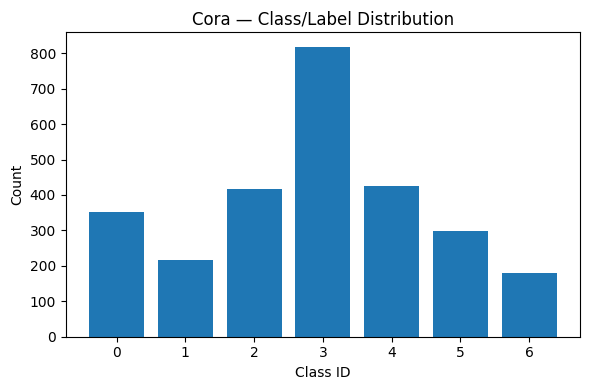

In [8]:
plt.figure(figsize=(6,4))
plt.bar(df_counts["class_id"].astype(str), df_counts["count"])
plt.title("Cora — Class/Label Distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Degree distribution plot

Avg degree: 3.90 | Median: 3 | Max: 168


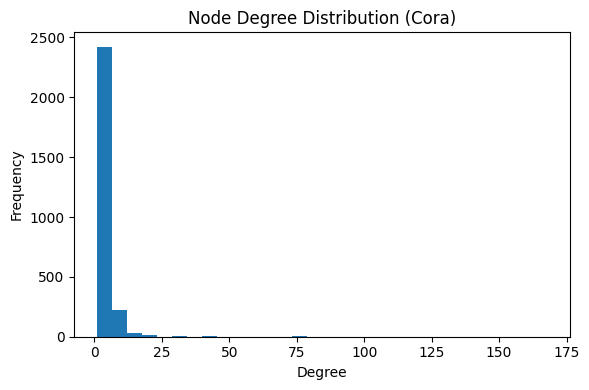

In [9]:
# Degree with PyG’s directed rep (ok for an undirected graph stored bidirectionally)
deg = torch.bincount(data.edge_index[0], minlength=num_nodes).cpu().numpy()

print(f"Avg degree: {deg.mean():.2f} | Median: {float(pd.Series(deg).median()):.0f} | Max: {deg.max()}")
plt.figure(figsize=(6,4))
plt.hist(deg, bins=30)
plt.title("Node Degree Distribution (Cora)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# GraphSAGE as defined in the template

In [10]:
class GraphSAGE(torch.nn.Module):
    """
    GraphSAGE model implementation.
    This class can be configured with a variable number of layers and different aggregators.
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, aggregator='mean', dropout=0.5):
        super(GraphSAGE, self).__init__()
        self.convs = torch.nn.ModuleList()

        # Input layer
        self.convs.append(SAGEConv(in_channels, hidden_channels, aggregator))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggregator))

        # Output layer
        self.convs.append(SAGEConv(hidden_channels, out_channels, aggregator))

        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            # Apply activation and dropout to all but the last layer
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(x, dim=1)


# GAT implementation ( Completed as defined in template )

In [11]:
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, heads=1, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        # First layer: in -> hidden * heads (concat=True)
        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads, concat=True, dropout=dropout))
        # Optional hidden layers (kept general)
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels, heads=heads, concat=True, dropout=dropout))
        # Final layer: hidden * heads -> out, heads=1, concat=False (per GAT paper)
        self.convs.append(GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
        return F.log_softmax(x, dim=1)

# Train and test functions ( Completed as defined in template )

In [12]:
def train(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return float(loss.item())

@torch.no_grad()
def test(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = int((pred[mask] == data.y[mask]).sum())
        total = int(mask.sum())
        accs.append(correct / total)
    return accs  # [train_acc, val_acc, test_acc]

# Function for running experiment ( Already defined in template )

In [13]:
def run_experiment(model, data, device, epochs=200, lr=0.01, weight_decay=5e-4):
    """
    Runs a full training and evaluation experiment for a given model.
    (This function is complete and does not need modification).
    """
    model = model.to(device)
    data = data.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.NLLLoss()

    best_val_acc = 0
    final_test_acc = 0

    for epoch in range(1, epochs + 1):
        loss = train(model, data, optimizer, criterion)
        train_acc, val_acc, test_acc = test(model, data)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            final_test_acc = test_acc

        if epoch % 20 == 0:
            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {train_acc:.4f}, '
                  f'Val: {val_acc:.4f}, Test: {test_acc:.4f}')

    return final_test_acc

# Helper functions to facilitate more analysis

## This is similar to test function but this returns entire list of predictions and not just scalar accuracy values

In [14]:
@torch.no_grad()
def _predict_on_mask(model, data, mask):
    model.eval()
    out  = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    y_true = data.y[mask].detach().cpu().numpy()
    y_pred = pred[mask].detach().cpu().numpy()
    return y_true, y_pred


## This stores accuracy and loss values and returns them which is used for plotting

In [15]:
def run_and_log(model, data, device, epochs=200, lr=0.01, weight_decay=5e-4, print_every=20):
    """
    Drop-in runner that logs epoch loss/acc using your existing train() and test().
    No changes to your other code required.
    """
    model = model.to(device)
    data  = data.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit  = torch.nn.NLLLoss()

    history = {"epoch": [], "loss": [], "train_acc": [], "val_acc": [], "test_acc": []}
    best = {"val_acc": -1.0, "test_acc": -1.0, "state": None}

    for epoch in range(1, epochs+1):
        loss = train(model, data, opt, crit)     # your train()
        tr, va, te = test(model, data)           # your test() -> [train,val,test]

        history["epoch"].append(epoch)
        history["loss"].append(float(loss))
        history["train_acc"].append(float(tr))
        history["val_acc"].append(float(va))
        history["test_acc"].append(float(te))

        if va > best["val_acc"]:
            best["val_acc"] = va
            best["test_acc"] = te
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % print_every == 0:
            print(f"Epoch {epoch:03d} | Loss {loss:.4f} | Train {tr:.4f} | Val {va:.4f} | Test {te:.4f}")

    # restore best-by-val weights for final evaluation/plots
    if best["state"] is not None:
        model.load_state_dict({k: v.to(device) for k, v in best["state"].items()})

    return model, history, best


## Helper for plotting accuracy and loss

In [16]:
def plot_curves(history, title_suffix=""):
    ep = history["epoch"]
    # loss
    plt.figure(figsize=(6,4))
    plt.plot(ep, history["loss"], label="Train loss")
    plt.xlabel("Epoch"); plt.ylabel("NLL Loss")
    plt.title(f"Loss{(' — ' + title_suffix) if title_suffix else ''}")
    plt.grid(True); plt.tight_layout(); plt.show()

    # accuracy
    plt.figure(figsize=(6,4))
    plt.plot(ep, history["train_acc"], label="Train")
    plt.plot(ep, history["val_acc"],   label="Val")
    plt.plot(ep, history["test_acc"],  label="Test")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"Accuracy{(' — ' + title_suffix) if title_suffix else ''}")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Helper for getting metrics

In [17]:
def print_test_metrics(model, data, title_suffix="", label_names=None):
    n_classes = int(data.y.max().item()) + 1
    labels_list = list(range(n_classes))

    y_true, y_pred = _predict_on_mask(model, data, data.test_mask)

    print(f"\n=== Test set metrics{(' — ' + title_suffix) if title_suffix else ''} ===")
    # Include all classes even if absent in test by specifying labels
    if label_names is not None and len(label_names) == n_classes:
        print(classification_report(y_true, y_pred, labels=labels_list,
                                    target_names=label_names, digits=4, zero_division=0))
    else:
        print(classification_report(y_true, y_pred, labels=labels_list,
                                    digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels_list)
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)

    # Heatmap
    plt.figure(figsize=(6,5))
    im = plt.imshow(cm, interpolation='nearest')
    plt.title(f"Confusion Matrix{(' — ' + title_suffix) if title_suffix else ''}")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ticklabels = label_names if (label_names and len(label_names)==n_classes) else labels_list
    plt.xticks(labels_list, ticklabels, rotation=45, ha="right")
    plt.yticks(labels_list, ticklabels)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()
    # Per-class table
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_list, zero_division=0
    )
    per_class_df = pd.DataFrame({
        "class_id": labels_list,
        "precision": p, "recall": r, "f1": f1, "support": support
    })
    display(per_class_df)
    return per_class_df, cm

# Autoencoder

## Why ?
**Because LSTM for 1433 input dimensions was giving OOM error. So as discussed in class for analyzing LSTM also I downproject the features using an Autoencoder**

In [18]:
# ===== 1) Autoencoder definition =====
import torch
import torch.nn as nn
import torch.nn.functional as F

class AE(nn.Module):
    def __init__(self, enc_dims=(1433, 512, 128), dec_dims=None, dropout=0.0):
        super().__init__()
        if dec_dims is None:
            dec_dims = (enc_dims[-1], enc_dims[-2], enc_dims[0])
        self.enc_layers = nn.ModuleList([
            nn.Linear(enc_dims[i], enc_dims[i+1]) for i in range(len(enc_dims)-1)
        ])
        self.dec_layers = nn.ModuleList([
            nn.Linear(dec_dims[i], dec_dims[i+1]) for i in range(len(dec_dims)-1)
        ])
        self.dropout = dropout

    def encode(self, x):
        for i, lin in enumerate(self.enc_layers):
            x = lin(x)
            if i < len(self.enc_layers)-1:
                x = F.relu(x)
                if self.dropout > 0:
                    x = F.dropout(x, p=self.dropout, training=self.training)
        return x  # latent z

    def decode(self, z):
        x = z
        for i, lin in enumerate(self.dec_layers):
            x = lin(x)
            if i < len(self.dec_layers)-1:
                x = F.relu(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        xr = self.decode(z)
        return xr, z

# ===== 2) Pretrain AE on node features (unsupervised) =====
@torch.no_grad()
def _standardize_cols(x):
    # Optional: column-wise standardization to help AE
    mu = x.mean(0, keepdim=True)
    sd = x.std(0, keepdim=True).clamp_min(1e-6)
    return (x - mu) / sd

def pretrain_autoencoder_features(data, proj_dim=128, epochs=100, lr=1e-3, weight_decay=1e-5, dropout=0.0, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    F_in = data.x.size(1)
    ae = AE(enc_dims=(F_in, max(256, proj_dim*2), proj_dim), dropout=dropout).to(device)
    opt = torch.optim.Adam(ae.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.MSELoss()

    x = data.x.to(device).float()
    x_std = _standardize_cols(x)  # helps reconstruction, optional

    ae.train()
    for ep in range(1, epochs+1):
        opt.zero_grad()
        xr, _ = ae(x_std)
        loss = crit(xr, x_std)
        loss.backward()
        opt.step()
        if ep % 20 == 0:
            print(f"[AE] Epoch {ep:03d} | recon MSE {loss.item():.6f}")

    ae.eval()
    return ae

# ===== 3) Replace data.x with encoder output =====
@torch.no_grad()
def apply_encoder_to_data(data, ae, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    x = data.x.to(device).float()
    x_std = _standardize_cols(x)
    z = ae.encode(x_std).detach()
    data_small = data.clone()
    data_small.x = z  # shape: [N, proj_dim]
    print("Replaced features:", int(x.size(1)), "→", int(z.size(1)))
    return data_small


## Helper for TSNE

In [19]:
# ---- Layerwise embeddings for N-layer GNNs (GraphSAGE/GAT) ----
import torch
from collections import OrderedDict

@torch.no_grad()
def layerwise_embeddings_N(model, data, mask=None):
    """
    Returns OrderedDict: ['input', 'h1', 'h2', ..., 'final'].
    Assumes model.convs is an iterable of message-passing layers.
    Hidden layers are AFTER activation; 'final' is PRE-softmax logits.
    """
    model.eval()
    x = data.x
    ei = data.edge_index

    out = OrderedDict()
    out["input"] = x

    is_gat = "gat" in model.__class__.__name__.lower()
    act = torch.nn.functional.elu if is_gat else torch.nn.functional.relu

    assert hasattr(model, "convs"), "Expected model.convs for this utility."
    L = len(model.convs)

    for i, conv in enumerate(model.convs):
        x = conv(x, ei)
        if i < L - 1:
            x = act(x)
            out[f"h{i+1}"] = x
        else:
            out["final"] = x  # pre-softmax logits

    # mask & numpy-ify
    def to_np(t):
        t = t[mask] if mask is not None else t
        return t.detach().cpu().numpy()

    return OrderedDict((k, to_np(v)) for k, v in out.items())


def plot_tsne_all(emb_dict, labels, title_prefix="", perplexity=30, random_state=42):
    """
    Makes one t-SNE plot per entry in emb_dict (input, h1, final).
    """
    y = labels if isinstance(labels, np.ndarray) else labels.cpu().numpy()
    for name, E in emb_dict.items():
        Z = TSNE(n_components=2, init="pca", learning_rate="auto",
                 perplexity=perplexity, random_state=random_state).fit_transform(E)
        plt.figure(figsize=(5,5))
        for c in np.unique(y):
            idx = (y==c)
            plt.scatter(Z[idx,0], Z[idx,1], s=8, alpha=0.7, label=str(c))
        plt.title(f"{title_prefix} — t-SNE of {name}")
        plt.legend(title="Class", bbox_to_anchor=(1.02,1), loc="upper left")
        plt.tight_layout(); plt.show()


# Experiments

## 1.  Full Input features ( 1433 ) . Apart from LSTM running for all

### Hyperparameters

In [20]:
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [21]:
hidden = 64
dropout = 0.5
epochs = 200
lr = 0.01
weight_decay = 5e-4
num_feats = data.x.size(1)

### GraphSAGE ( mean, max )

In [22]:
_ = setup_environment(42)
aggregators = ['mean', 'max']  # lstm is supported by SAGEConv.  # see docs
sage_results = {}

for aggr in aggregators:
    print(f'\n=== GraphSAGE | aggr={aggr} ===')
    model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator=aggr, dropout=dropout)
    test_acc = run_experiment(model, data, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GraphSAGE full {aggr})',count_params(model))
    sage_results[aggr] = test_acc

sage_df = pd.DataFrame(
    [{'Aggregator': k, 'Test Accuracy (%)': round(v * 100, 2)} for k, v in sage_results.items()]
).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

best_aggr = sage_df.loc[0, 'Aggregator']
print('\nGraphSAGE results:')
print(sage_df.to_string(index=False))
print(f'\nBest GraphSAGE aggregator: {best_aggr}')


Using device: cuda

=== GraphSAGE | aggr=mean ===
Epoch: 020, Loss: 0.0009, Train: 1.0000, Val: 0.7660, Test: 0.7920
Epoch: 040, Loss: 0.0035, Train: 1.0000, Val: 0.7640, Test: 0.7950
Epoch: 060, Loss: 0.0044, Train: 1.0000, Val: 0.7760, Test: 0.8110
Epoch: 080, Loss: 0.0036, Train: 1.0000, Val: 0.7780, Test: 0.8100
Epoch: 100, Loss: 0.0048, Train: 1.0000, Val: 0.7700, Test: 0.8060
Epoch: 120, Loss: 0.0051, Train: 1.0000, Val: 0.7780, Test: 0.8030
Epoch: 140, Loss: 0.0039, Train: 1.0000, Val: 0.7780, Test: 0.8100
Epoch: 160, Loss: 0.0040, Train: 1.0000, Val: 0.7720, Test: 0.8140
Epoch: 180, Loss: 0.0048, Train: 1.0000, Val: 0.7800, Test: 0.8130
Epoch: 200, Loss: 0.0033, Train: 1.0000, Val: 0.7700, Test: 0.8140
Params (GraphSAGE full mean) 184391

=== GraphSAGE | aggr=max ===


/usr/local/lib/python3.12/dist-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Epoch: 020, Loss: 0.0032, Train: 1.0000, Val: 0.7600, Test: 0.7680
Epoch: 040, Loss: 0.0025, Train: 1.0000, Val: 0.7420, Test: 0.7710
Epoch: 060, Loss: 0.0016, Train: 1.0000, Val: 0.7460, Test: 0.7750
Epoch: 080, Loss: 0.0016, Train: 1.0000, Val: 0.7460, Test: 0.7620
Epoch: 100, Loss: 0.0021, Train: 1.0000, Val: 0.7640, Test: 0.7710
Epoch: 120, Loss: 0.0023, Train: 1.0000, Val: 0.7680, Test: 0.7520
Epoch: 140, Loss: 0.0014, Train: 1.0000, Val: 0.7640, Test: 0.7820
Epoch: 160, Loss: 0.0025, Train: 1.0000, Val: 0.7760, Test: 0.7860
Epoch: 180, Loss: 0.0026, Train: 1.0000, Val: 0.7720, Test: 0.7900
Epoch: 200, Loss: 0.0019, Train: 1.0000, Val: 0.7660, Test: 0.7680
Params (GraphSAGE full max) 184391

GraphSAGE results:
Aggregator  Test Accuracy (%)
      mean               80.8
       max               78.5

Best GraphSAGE aggregator: mean


### Mean aggregator gives the best result so detailed analysis

Using device: cuda
Epoch 020 | Loss 0.0009 | Train 1.0000 | Val 0.7660 | Test 0.7920
Epoch 040 | Loss 0.0035 | Train 1.0000 | Val 0.7640 | Test 0.7950
Epoch 060 | Loss 0.0044 | Train 1.0000 | Val 0.7760 | Test 0.8110
Epoch 080 | Loss 0.0036 | Train 1.0000 | Val 0.7780 | Test 0.8100
Epoch 100 | Loss 0.0048 | Train 1.0000 | Val 0.7700 | Test 0.8060
Epoch 120 | Loss 0.0051 | Train 1.0000 | Val 0.7780 | Test 0.8030
Epoch 140 | Loss 0.0039 | Train 1.0000 | Val 0.7780 | Test 0.8100
Epoch 160 | Loss 0.0040 | Train 1.0000 | Val 0.7720 | Test 0.8140
Epoch 180 | Loss 0.0048 | Train 1.0000 | Val 0.7800 | Test 0.8130
Epoch 200 | Loss 0.0033 | Train 1.0000 | Val 0.7700 | Test 0.8140


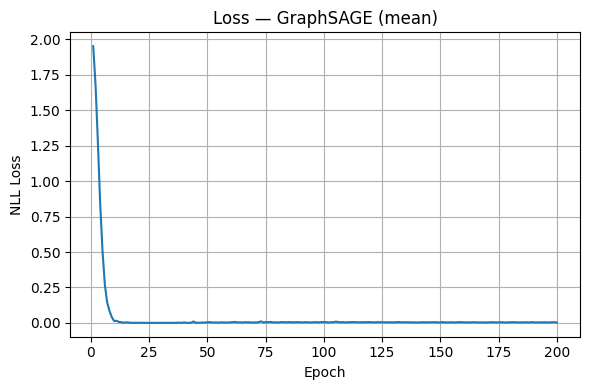

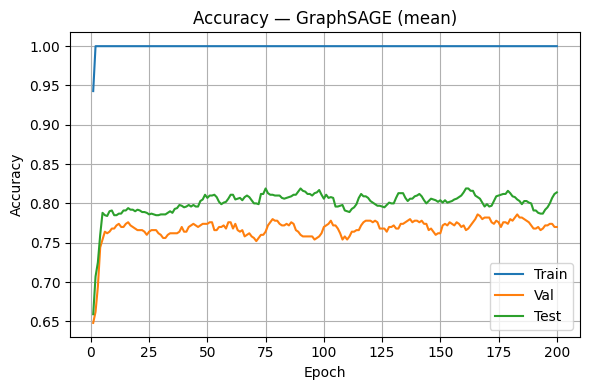


=== Test set metrics — GraphSAGE (mean) ===
              precision    recall  f1-score   support

           0     0.7417    0.6846    0.7120       130
           1     0.7961    0.9011    0.8454        91
           2     0.8973    0.9097    0.9034       144
           3     0.8901    0.7618    0.8209       319
           4     0.7853    0.8591    0.8205       149
           5     0.7778    0.7476    0.7624       103
           6     0.6042    0.9062    0.7250        64

    accuracy                         0.8080      1000
   macro avg     0.7846    0.8243    0.7985      1000
weighted avg     0.8178    0.8080    0.8086      1000

Confusion matrix (rows=true, cols=pred):
[[ 89   4   2  10   7   3  15]
 [  2  82   2   3   0   1   1]
 [  2   4 131   6   0   1   0]
 [ 15   8   7 243  28   9   9]
 [  4   1   0   9 128   6   1]
 [  6   3   4   1   0  77  12]
 [  2   1   0   1   0   2  58]]


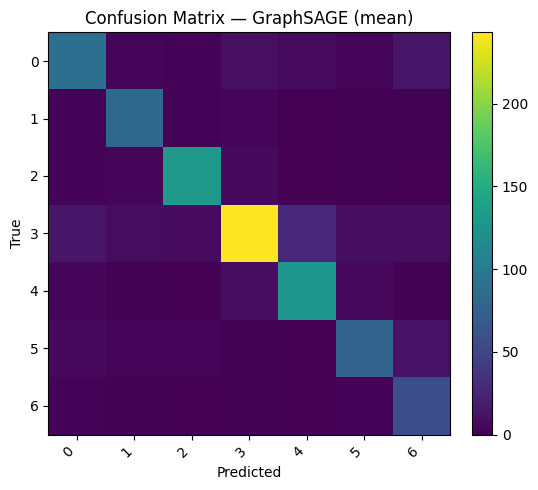

,class_id,precision,recall,f1,support
0,0,0.741667,0.684615,0.712000,130
1,1,0.796117,0.901099,0.845361,91
2,2,0.897260,0.909722,0.903448,144
3,3,0.890110,0.761755,0.820946,319
4,4,0.785276,0.859060,0.820513,149
5,5,0.777778,0.747573,0.762376,103
6,6,0.604167,0.906250,0.725000,64


In [23]:
# use the AE-compressed features (this is what fixed LSTM for you)
data_used = data

num_feats = data_used.x.size(1)
num_classes = int(data_used.y.max()) + 1
_ = setup_environment(42)

model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator='mean', dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GraphSAGE (mean)")
_ = print_test_metrics(model, data_used, title_suffix="GraphSAGE (mean)")


### GAT ( 1 , 2 and 5 heads )

In [24]:
gat_heads_list = [1, 2, 5]  # requested variants
gat_results = {}

_ = setup_environment(42)


for heads in gat_heads_list:
    print(f'\n=== GAT | heads={heads} ===')
    model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=heads, dropout=dropout)  # same hyperparams
    test_acc = run_experiment(model, data, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GAT full {heads})',count_params(model))
    gat_results[heads] = test_acc

gat_df = pd.DataFrame(
    [{'Heads': h, 'Test Accuracy (%)': round(acc * 100, 2)} for h, acc in gat_results.items()]
).sort_values('Heads').reset_index(drop=True)

print('\nGAT results:')
print(gat_df.to_string(index=False))



Using device: cuda

=== GAT | heads=1 ===
Epoch: 020, Loss: 0.5166, Train: 0.9929, Val: 0.7740, Test: 0.8100
Epoch: 040, Loss: 0.3945, Train: 1.0000, Val: 0.7620, Test: 0.7800
Epoch: 060, Loss: 0.4012, Train: 1.0000, Val: 0.7800, Test: 0.7940
Epoch: 080, Loss: 0.2792, Train: 1.0000, Val: 0.7640, Test: 0.7810
Epoch: 100, Loss: 0.3238, Train: 1.0000, Val: 0.7700, Test: 0.8020
Epoch: 120, Loss: 0.2575, Train: 1.0000, Val: 0.7640, Test: 0.7880
Epoch: 140, Loss: 0.2855, Train: 1.0000, Val: 0.7680, Test: 0.8020
Epoch: 160, Loss: 0.2704, Train: 1.0000, Val: 0.7780, Test: 0.8090
Epoch: 180, Loss: 0.3056, Train: 1.0000, Val: 0.7420, Test: 0.7580
Epoch: 200, Loss: 0.2707, Train: 1.0000, Val: 0.7600, Test: 0.7810
Params (GAT full 1) 92373

=== GAT | heads=2 ===
Epoch: 020, Loss: 0.4426, Train: 1.0000, Val: 0.7780, Test: 0.7950
Epoch: 040, Loss: 0.3452, Train: 1.0000, Val: 0.7700, Test: 0.7940
Epoch: 060, Loss: 0.3509, Train: 1.0000, Val: 0.7540, Test: 0.7930
Epoch: 080, Loss: 0.2856, Train: 1.000

### 1 head gave best results so analysis

Using device: cuda
Epoch 020 | Loss 0.5166 | Train 0.9929 | Val 0.7740 | Test 0.8100
Epoch 040 | Loss 0.3945 | Train 1.0000 | Val 0.7620 | Test 0.7800
Epoch 060 | Loss 0.4012 | Train 1.0000 | Val 0.7800 | Test 0.7940
Epoch 080 | Loss 0.2792 | Train 1.0000 | Val 0.7640 | Test 0.7810
Epoch 100 | Loss 0.3238 | Train 1.0000 | Val 0.7700 | Test 0.8020
Epoch 120 | Loss 0.2575 | Train 1.0000 | Val 0.7640 | Test 0.7880
Epoch 140 | Loss 0.2855 | Train 1.0000 | Val 0.7680 | Test 0.8020
Epoch 160 | Loss 0.2704 | Train 1.0000 | Val 0.7780 | Test 0.8090
Epoch 180 | Loss 0.3056 | Train 1.0000 | Val 0.7420 | Test 0.7580
Epoch 200 | Loss 0.2707 | Train 1.0000 | Val 0.7600 | Test 0.7810


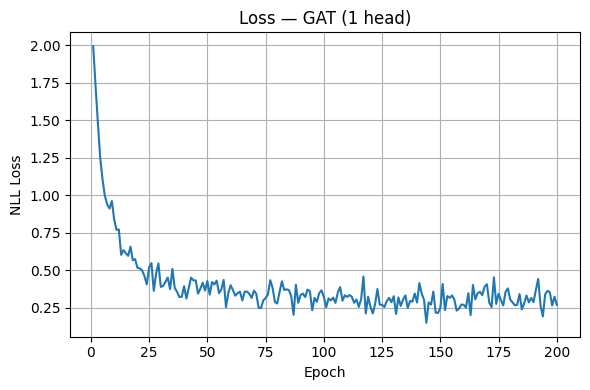

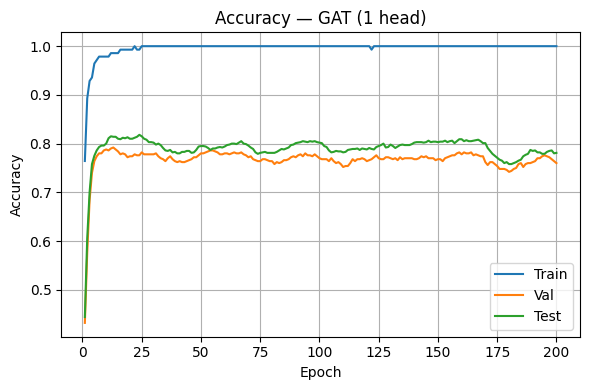


=== Test set metrics — GAT (1 head ===
              precision    recall  f1-score   support

           0     0.7209    0.7154    0.7181       130
           1     0.7957    0.8132    0.8043        91
           2     0.8874    0.9306    0.9085       144
           3     0.8750    0.8339    0.8539       319
           4     0.8583    0.7315    0.7899       149
           5     0.7069    0.7961    0.7489       103
           6     0.7000    0.8750    0.7778        64

    accuracy                         0.8140      1000
   macro avg     0.7920    0.8137    0.8002      1000
weighted avg     0.8185    0.8140    0.8144      1000

Confusion matrix (rows=true, cols=pred):
[[ 93   5   3   9   3   8   9]
 [  4  74   5   7   0   1   0]
 [  1   1 134   6   1   1   0]
 [ 11   7   5 266  14  11   5]
 [ 10   3   0  14 109  11   2]
 [  5   3   4   1   0  82   8]
 [  5   0   0   1   0   2  56]]


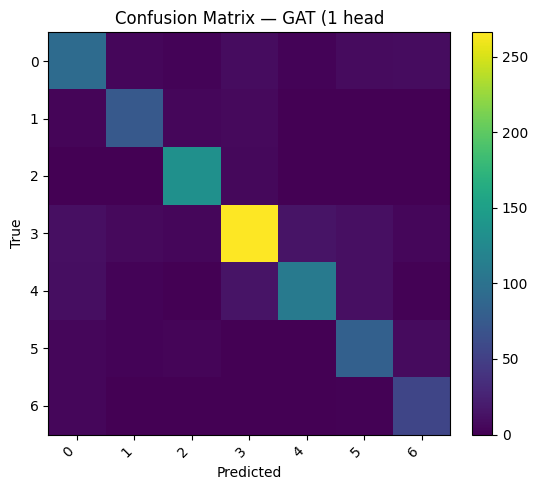

,class_id,precision,recall,f1,support
0,0,0.720930,0.715385,0.718147,130
1,1,0.795699,0.813187,0.804348,91
2,2,0.887417,0.930556,0.908475,144
3,3,0.875000,0.833856,0.853933,319
4,4,0.858268,0.731544,0.789855,149
5,5,0.706897,0.796117,0.748858,103
6,6,0.700000,0.875000,0.777778,64


In [25]:
_ = setup_environment(42)

model = model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=1, dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GAT (1 head)")
_ = print_test_metrics(model, data_used, title_suffix="GAT (1 head")

### Comparison

In [26]:
# Simple comparison table (best of each family)
best_gat_heads = max(gat_results, key=lambda h: gat_results[h])
compare_df = pd.DataFrame({
    'Model': ['GraphSAGE (best)', 'GAT (best)'],
    'Config': [f'Aggregator={best_aggr}', f'Heads={best_gat_heads}'],
    'Test Accuracy (%)': [round(sage_results[best_aggr]*100, 2), round(gat_results[best_gat_heads]*100, 2)]
})
print('\nComparison:')
print(compare_df.to_string(index=False))



Comparison:
           Model          Config  Test Accuracy (%)
GraphSAGE (best) Aggregator=mean               80.8
      GAT (best)         Heads=1               81.4


## As GAT Model gives the best results I am plotting tsne plots for it to see feature discriminativeness as layers progress

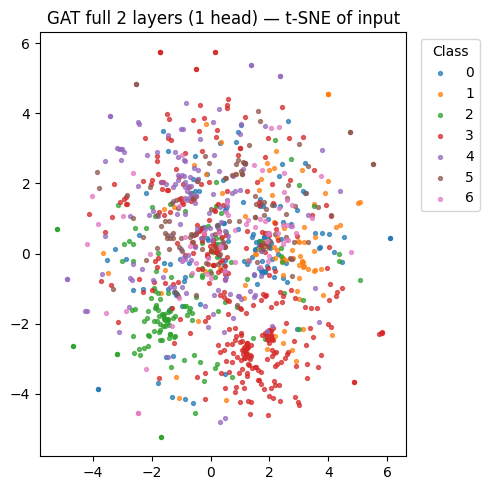

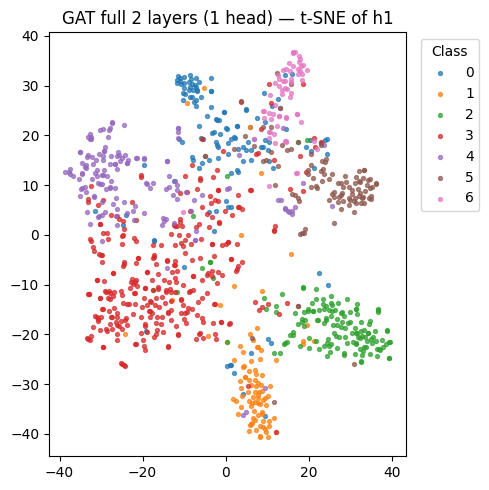

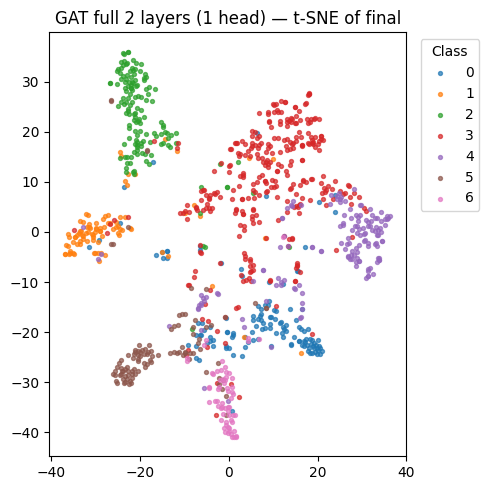

In [27]:
from sklearn.manifold import TSNE
embs = layerwise_embeddings_N(model, data, mask=data.test_mask)
labels = data.y[data.test_mask]
plot_tsne_all(embs, labels, title_prefix="GAT full 2 layers (1 head)")

In [28]:
model = GAT(num_feats, hidden, num_classes, num_layers=15, heads=heads, dropout=dropout)  # same hyperparams
test_acc = run_experiment(model, data, device, epochs=epochs, lr=lr, weight_decay=weight_decay)

Epoch: 020, Loss: 6517.7832, Train: 0.1429, Val: 0.1220, Test: 0.1300
Epoch: 040, Loss: 86586.6797, Train: 0.1429, Val: 0.1620, Test: 0.1490
Epoch: 060, Loss: 174118.1719, Train: 0.1429, Val: 0.1640, Test: 0.1450
Epoch: 080, Loss: 707102.7500, Train: 0.1429, Val: 0.0580, Test: 0.0640
Epoch: 100, Loss: 2870512.0000, Train: 0.1429, Val: 0.0580, Test: 0.0640
Epoch: 120, Loss: 3229100.0000, Train: 0.1429, Val: 0.3160, Test: 0.3190
Epoch: 140, Loss: 11256254.0000, Train: 0.1429, Val: 0.3160, Test: 0.3190
Epoch: 160, Loss: 5889191.5000, Train: 0.1429, Val: 0.3160, Test: 0.3190
Epoch: 180, Loss: 2337593.0000, Train: 0.1429, Val: 0.0580, Test: 0.0640
Epoch: 200, Loss: 1575026.6250, Train: 0.1429, Val: 0.0580, Test: 0.0640


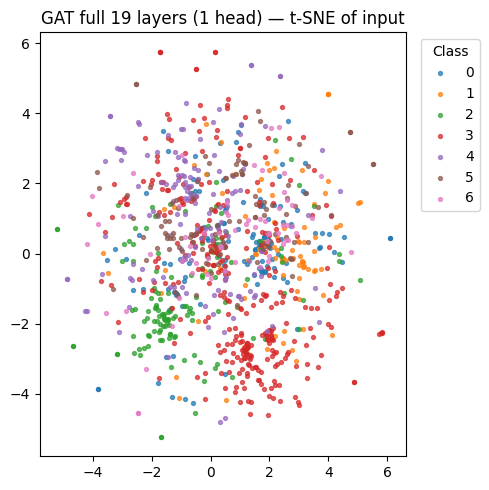

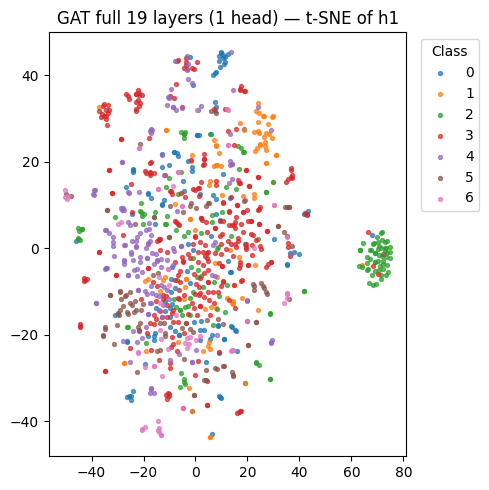

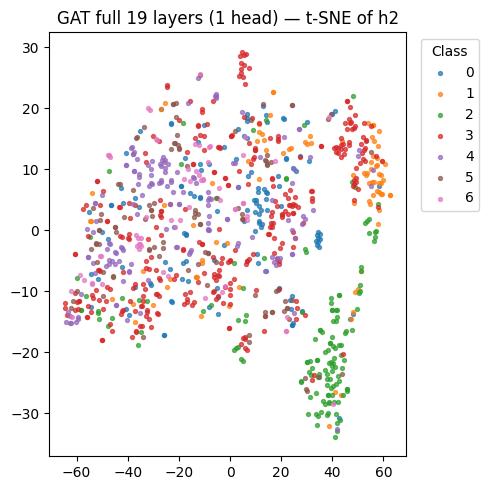

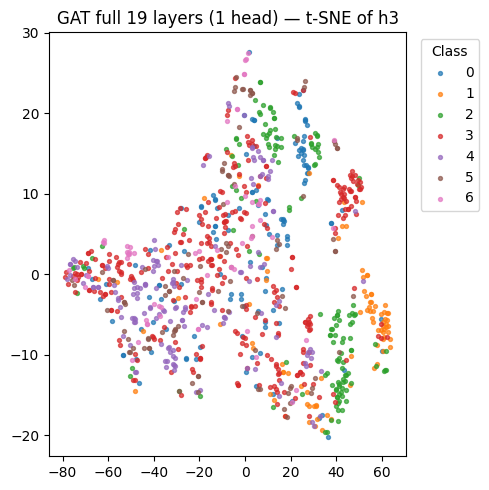

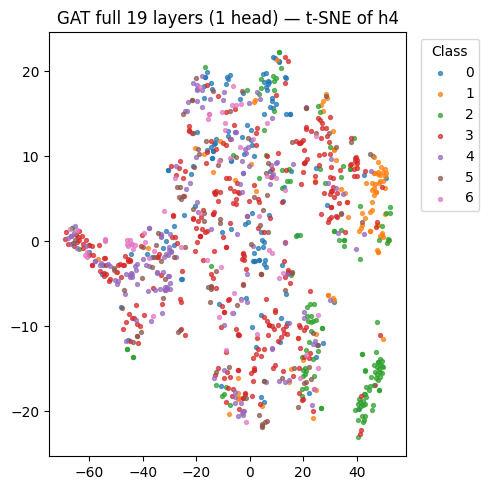

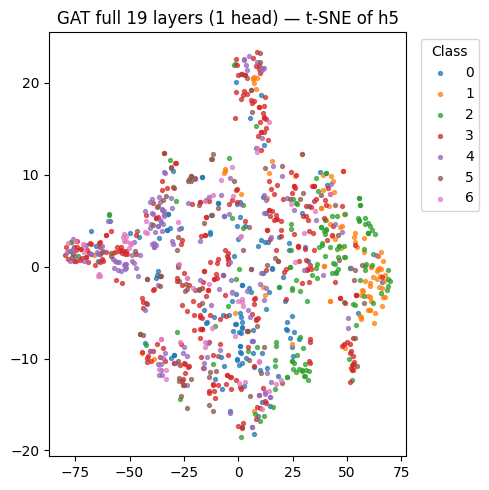

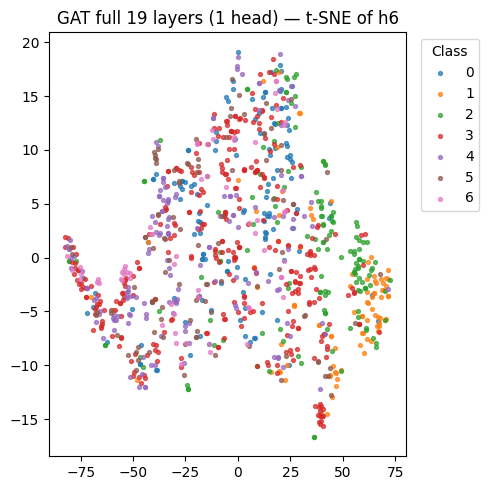

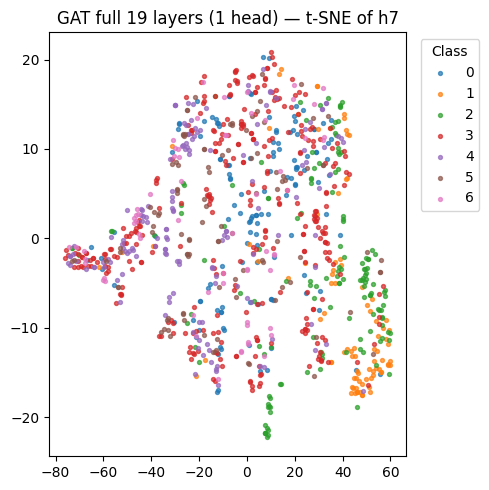

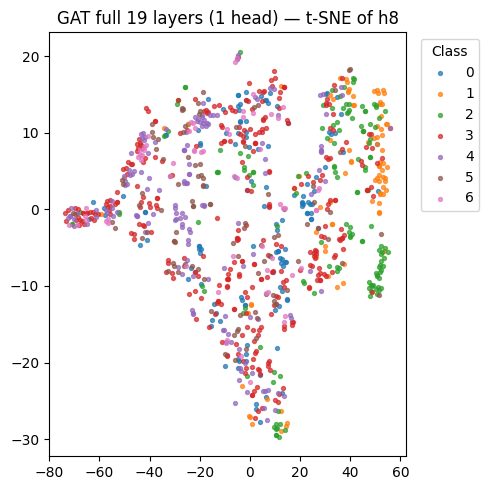

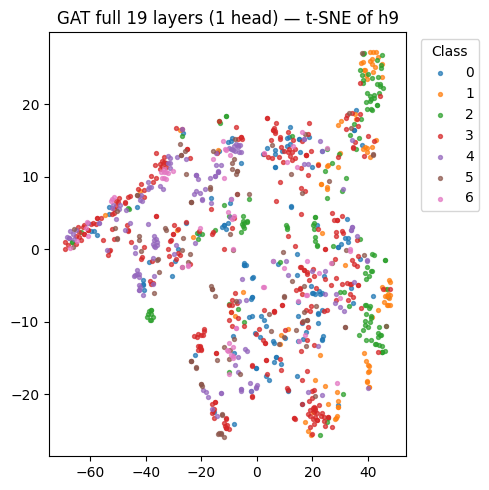

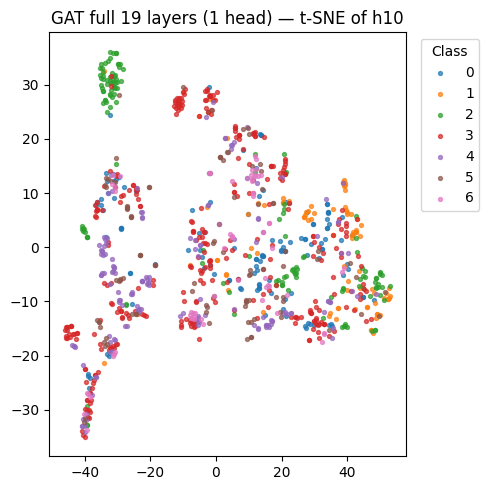

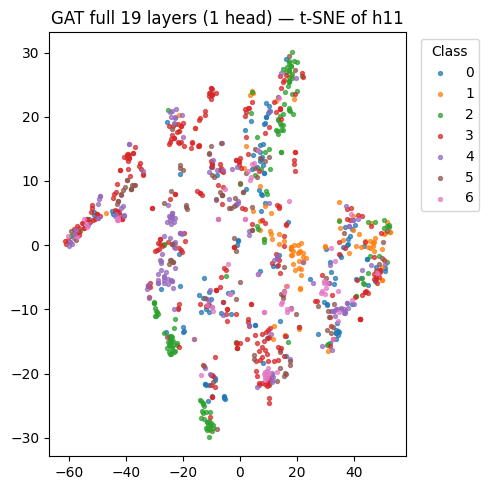

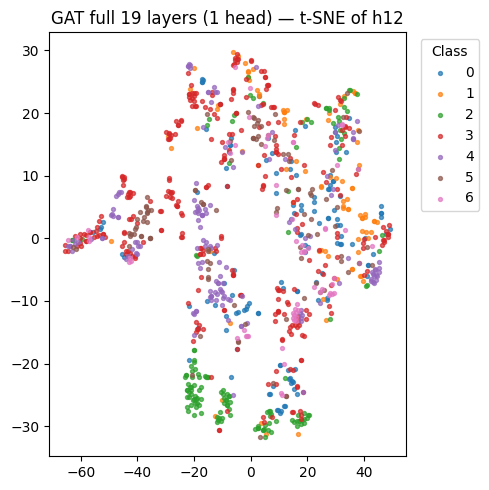

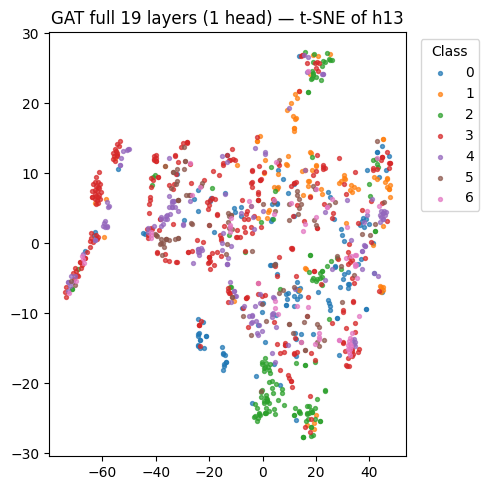

In [ ]:
from sklearn.manifold import TSNE
embs = layerwise_embeddings_N(model, data, mask=data.test_mask)
labels = data.y[data.test_mask]
plot_tsne_all(embs, labels, title_prefix="GAT full 19 layers (1 head)")

## 2.  Reduced features via autoencoder ( dim = 64 )

In [27]:
proj_dim = 64
_ = setup_environment(42)

ae = pretrain_autoencoder_features(data, proj_dim=proj_dim, epochs=100, lr=1e-3, weight_decay=1e-5, dropout=0.1, device=device)
data_64 = apply_encoder_to_data(data, ae, device=device)


Using device: cuda
[AE] Epoch 020 | recon MSE 0.951467
[AE] Epoch 040 | recon MSE 0.892729
[AE] Epoch 060 | recon MSE 0.846507
[AE] Epoch 080 | recon MSE 0.801323
[AE] Epoch 100 | recon MSE 0.763948
Replaced features: 1433 → 64


### Hyperparameters

In [28]:
hidden = 64
dropout = 0.5
epochs = 200
lr = 0.01
weight_decay = 5e-4
num_feats = data_64.x.size(1)

### GraphSAGE ( mean , max , lstm )

In [29]:
_ = setup_environment(42)
aggregators = ['mean', 'max','lstm']  # lstm is supported by SAGEConv.  # see docs
sage_results = {}

for aggr in aggregators:
    print(f'\n=== GraphSAGE | aggr={aggr} ===')
    model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator=aggr, dropout=dropout)
    test_acc = run_experiment(model, data_64, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GraphSAGE 64 {aggr})',count_params(model))
    sage_results[aggr] = test_acc

sage_df = pd.DataFrame(
    [{'Aggregator': k, 'Test Accuracy (%)': round(v * 100, 2)} for k, v in sage_results.items()]
).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

best_aggr = sage_df.loc[0, 'Aggregator']
print('\nGraphSAGE 64 results:')
print(sage_df.to_string(index=False))
print(f'\nBest GraphSAGE aggregator: {best_aggr}')


Using device: cuda

=== GraphSAGE | aggr=mean ===
Epoch: 020, Loss: 0.0388, Train: 1.0000, Val: 0.7420, Test: 0.7690
Epoch: 040, Loss: 0.0038, Train: 1.0000, Val: 0.7100, Test: 0.7470
Epoch: 060, Loss: 0.0015, Train: 1.0000, Val: 0.7260, Test: 0.7480
Epoch: 080, Loss: 0.0047, Train: 1.0000, Val: 0.7240, Test: 0.7490
Epoch: 100, Loss: 0.0045, Train: 1.0000, Val: 0.7380, Test: 0.7570
Epoch: 120, Loss: 0.0018, Train: 1.0000, Val: 0.7420, Test: 0.7630
Epoch: 140, Loss: 0.0008, Train: 1.0000, Val: 0.7440, Test: 0.7610
Epoch: 160, Loss: 0.0019, Train: 1.0000, Val: 0.7440, Test: 0.7600
Epoch: 180, Loss: 0.0012, Train: 1.0000, Val: 0.7400, Test: 0.7560
Epoch: 200, Loss: 0.0014, Train: 1.0000, Val: 0.7300, Test: 0.7530
Params (GraphSAGE 64 mean) 9159

=== GraphSAGE | aggr=max ===
Epoch: 020, Loss: 0.1386, Train: 1.0000, Val: 0.6960, Test: 0.7050


/usr/local/lib/python3.12/dist-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Epoch: 040, Loss: 0.0297, Train: 1.0000, Val: 0.7180, Test: 0.7150
Epoch: 060, Loss: 0.0111, Train: 1.0000, Val: 0.6900, Test: 0.6980
Epoch: 080, Loss: 0.0145, Train: 1.0000, Val: 0.7060, Test: 0.6900
Epoch: 100, Loss: 0.0108, Train: 1.0000, Val: 0.6860, Test: 0.7000
Epoch: 120, Loss: 0.0039, Train: 1.0000, Val: 0.6980, Test: 0.7190
Epoch: 140, Loss: 0.0062, Train: 1.0000, Val: 0.7180, Test: 0.7250
Epoch: 160, Loss: 0.0039, Train: 1.0000, Val: 0.7040, Test: 0.7190
Epoch: 180, Loss: 0.0009, Train: 1.0000, Val: 0.7120, Test: 0.7260
Epoch: 200, Loss: 0.0019, Train: 1.0000, Val: 0.7160, Test: 0.7280
Params (GraphSAGE 64 max) 9159

=== GraphSAGE | aggr=lstm ===
Epoch: 020, Loss: 0.4095, Train: 0.9786, Val: 0.4960, Test: 0.5590
Epoch: 040, Loss: 0.1145, Train: 1.0000, Val: 0.4980, Test: 0.5700
Epoch: 060, Loss: 0.0770, Train: 1.0000, Val: 0.4920, Test: 0.5740
Epoch: 080, Loss: 0.0472, Train: 1.0000, Val: 0.4900, Test: 0.5790
Epoch: 100, Loss: 0.0235, Train: 1.0000, Val: 0.4880, Test: 0.5710


### Mean gives best results

Using device: cuda
Epoch 020 | Loss 0.0388 | Train 1.0000 | Val 0.7420 | Test 0.7690
Epoch 040 | Loss 0.0038 | Train 1.0000 | Val 0.7100 | Test 0.7470
Epoch 060 | Loss 0.0015 | Train 1.0000 | Val 0.7260 | Test 0.7480
Epoch 080 | Loss 0.0047 | Train 1.0000 | Val 0.7240 | Test 0.7490
Epoch 100 | Loss 0.0045 | Train 1.0000 | Val 0.7380 | Test 0.7570
Epoch 120 | Loss 0.0018 | Train 1.0000 | Val 0.7420 | Test 0.7630
Epoch 140 | Loss 0.0008 | Train 1.0000 | Val 0.7440 | Test 0.7610
Epoch 160 | Loss 0.0019 | Train 1.0000 | Val 0.7440 | Test 0.7600
Epoch 180 | Loss 0.0012 | Train 1.0000 | Val 0.7400 | Test 0.7560
Epoch 200 | Loss 0.0014 | Train 1.0000 | Val 0.7300 | Test 0.7530


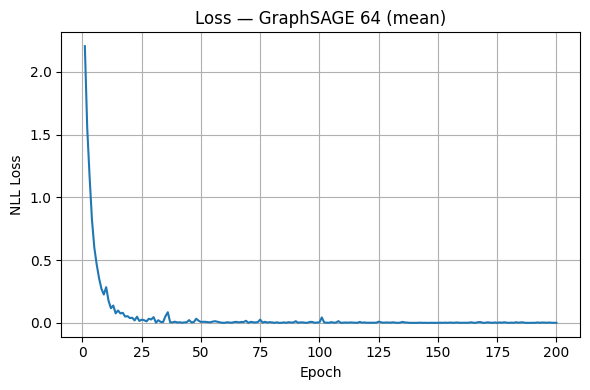

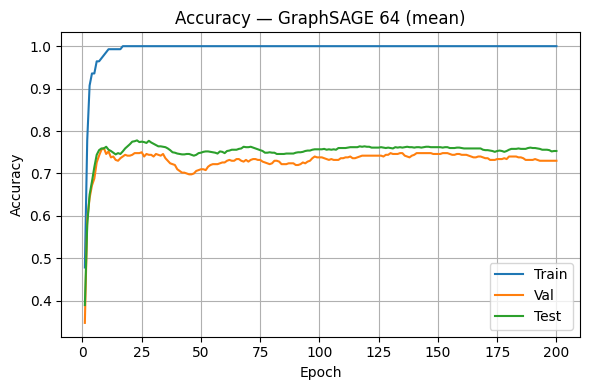


=== Test set metrics — GraphSAGE 64 (mean) ===
              precision    recall  f1-score   support

           0     0.5901    0.7308    0.6529       130
           1     0.7400    0.8132    0.7749        91
           2     0.8389    0.8681    0.8532       144
           3     0.8759    0.7304    0.7966       319
           4     0.7134    0.7517    0.7320       149
           5     0.7812    0.7282    0.7538       103
           6     0.6338    0.7031    0.6667        64

    accuracy                         0.7590      1000
   macro avg     0.7391    0.7608    0.7472      1000
weighted avg     0.7716    0.7590    0.7617      1000

Confusion matrix (rows=true, cols=pred):
[[ 95   4   3   8   4   3  13]
 [  5  74   2   5   2   3   0]
 [  3   8 125   5   0   3   0]
 [ 16   5  12 233  39   8   6]
 [ 17   6   3   9 112   1   1]
 [ 11   2   4   5   0  75   6]
 [ 14   1   0   1   0   3  45]]


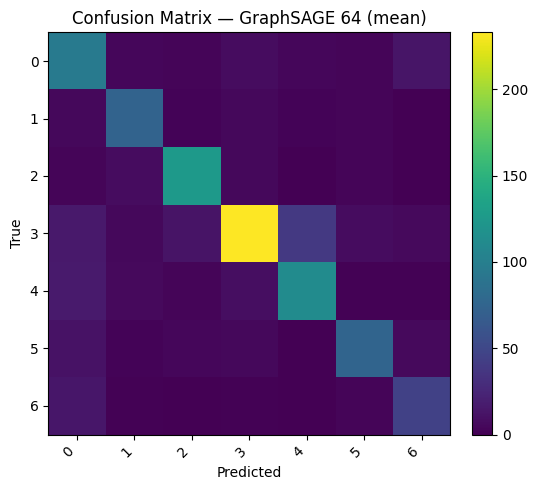

,class_id,precision,recall,f1,support
0,0,0.590062,0.730769,0.652921,130
1,1,0.740000,0.813187,0.774869,91
2,2,0.838926,0.868056,0.853242,144
3,3,0.875940,0.730408,0.796581,319
4,4,0.713376,0.751678,0.732026,149
5,5,0.781250,0.728155,0.753769,103
6,6,0.633803,0.703125,0.666667,64


In [30]:
# use the AE-compressed features (this is what fixed LSTM for you)
data_used = data_64

num_feats = data_used.x.size(1)
num_classes = int(data_used.y.max()) + 1
_ = setup_environment(42)

model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator='mean', dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GraphSAGE 64 (mean)")
_ = print_test_metrics(model, data_used, title_suffix="GraphSAGE 64 (mean)")


### GAT ( 1, 2 and 5 heads )

In [31]:
gat_heads_list = [1, 2, 5]  # requested variants
gat_results = {}

_ = setup_environment(42)


for heads in gat_heads_list:
    print(f'\n=== GAT | heads={heads} ===')
    model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=heads, dropout=dropout)  # same hyperparams
    test_acc = run_experiment(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GAT 64 {heads})',count_params(model))
    gat_results[heads] = test_acc

gat_df = pd.DataFrame(
    [{'Heads': h, 'Test Accuracy (%)': round(acc * 100, 2)} for h, acc in gat_results.items()]
).sort_values('Heads').reset_index(drop=True)

print('\nGAT 64 results:')
print(gat_df.to_string(index=False))



Using device: cuda

=== GAT | heads=1 ===
Epoch: 020, Loss: 2.3650, Train: 0.5143, Val: 0.3580, Test: 0.4160
Epoch: 040, Loss: 2.1413, Train: 0.6143, Val: 0.4540, Test: 0.5200
Epoch: 060, Loss: 2.3478, Train: 0.7857, Val: 0.5440, Test: 0.6070
Epoch: 080, Loss: 1.5147, Train: 0.8000, Val: 0.6000, Test: 0.6560
Epoch: 100, Loss: 1.4139, Train: 0.8357, Val: 0.6740, Test: 0.6800
Epoch: 120, Loss: 1.3386, Train: 0.8929, Val: 0.6880, Test: 0.6970
Epoch: 140, Loss: 1.2444, Train: 0.8857, Val: 0.7100, Test: 0.7260
Epoch: 160, Loss: 1.0170, Train: 0.9143, Val: 0.7340, Test: 0.7350
Epoch: 180, Loss: 0.9602, Train: 0.9357, Val: 0.7440, Test: 0.7560
Epoch: 200, Loss: 0.9837, Train: 0.9357, Val: 0.7300, Test: 0.7290
Params (GAT 64 1) 4757

=== GAT | heads=2 ===
Epoch: 020, Loss: 1.7883, Train: 0.7714, Val: 0.5960, Test: 0.6480
Epoch: 040, Loss: 1.5640, Train: 0.8071, Val: 0.6600, Test: 0.6940
Epoch: 060, Loss: 1.5335, Train: 0.8929, Val: 0.6820, Test: 0.7220
Epoch: 080, Loss: 1.1478, Train: 0.9143, 

### 2 head gives best results

Using device: cuda
Epoch 020 | Loss 2.0294 | Train 0.8000 | Val 0.5820 | Test 0.6090
Epoch 040 | Loss 1.5838 | Train 0.8857 | Val 0.6440 | Test 0.6870
Epoch 060 | Loss 1.3945 | Train 0.9143 | Val 0.6840 | Test 0.7010
Epoch 080 | Loss 1.0666 | Train 0.9429 | Val 0.7100 | Test 0.7240
Epoch 100 | Loss 0.9027 | Train 0.9500 | Val 0.7240 | Test 0.7480
Epoch 120 | Loss 0.7512 | Train 0.9643 | Val 0.7320 | Test 0.7600
Epoch 140 | Loss 0.8181 | Train 0.9714 | Val 0.7380 | Test 0.7690
Epoch 160 | Loss 0.6386 | Train 0.9786 | Val 0.7360 | Test 0.7790
Epoch 180 | Loss 0.6038 | Train 0.9714 | Val 0.7380 | Test 0.7830
Epoch 200 | Loss 0.6407 | Train 0.9714 | Val 0.7480 | Test 0.7910


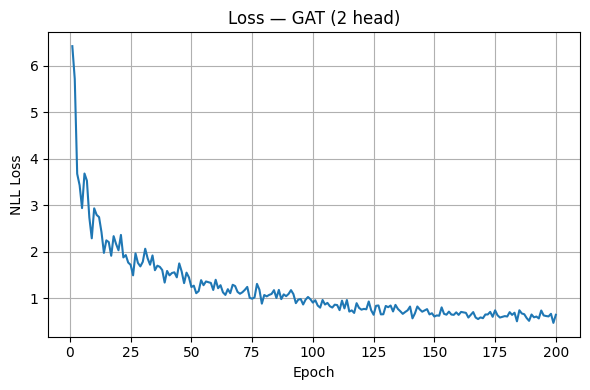

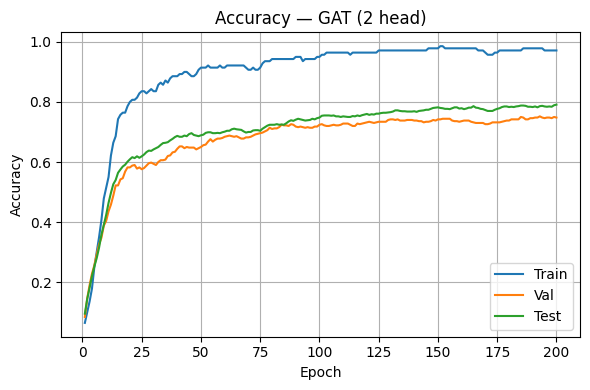


=== Test set metrics — GAT (2 head ===
              precision    recall  f1-score   support

           0     0.6562    0.8077    0.7241       130
           1     0.7830    0.9121    0.8426        91
           2     0.8442    0.9028    0.8725       144
           3     0.9455    0.6520    0.7718       319
           4     0.6961    0.8456    0.7636       149
           5     0.8000    0.7767    0.7882       103
           6     0.6835    0.8438    0.7552        64

    accuracy                         0.7860      1000
   macro avg     0.7727    0.8201    0.7883      1000
weighted avg     0.8096    0.7860    0.7860      1000

Confusion matrix (rows=true, cols=pred):
[[105   4   4   4   6   0   7]
 [  4  83   1   3   0   0   0]
 [  2   4 130   3   1   3   1]
 [ 18  10  14 208  48  13   8]
 [ 14   3   1   2 126   2   1]
 [ 10   1   4   0   0  80   8]
 [  7   1   0   0   0   2  54]]


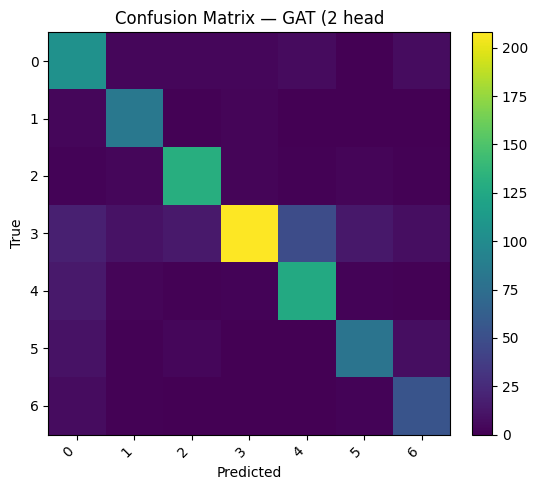

,class_id,precision,recall,f1,support
0,0,0.656250,0.807692,0.724138,130
1,1,0.783019,0.912088,0.842640,91
2,2,0.844156,0.902778,0.872483,144
3,3,0.945455,0.652038,0.771800,319
4,4,0.696133,0.845638,0.763636,149
5,5,0.800000,0.776699,0.788177,103
6,6,0.683544,0.843750,0.755245,64


In [32]:
_ = setup_environment(42)

model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=2, dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GAT (2 head)")
_ = print_test_metrics(model, data_used, title_suffix="GAT (2 head")

### Comparison

In [33]:
# Simple comparison table (best of each family)
best_gat_heads = max(gat_results, key=lambda h: gat_results[h])
compare_df = pd.DataFrame({
    'Model': ['GraphSAGE (best)', 'GAT (best)'],
    'Config': [f'Aggregator={best_aggr}', f'Heads={best_gat_heads}'],
    'Test Accuracy (%)': [round(sage_results[best_aggr]*100, 2), round(gat_results[best_gat_heads]*100, 2)]
})
print('\nComparison:')
print(compare_df.to_string(index=False))



Comparison:
           Model          Config  Test Accuracy (%)
GraphSAGE (best) Aggregator=mean               75.9
      GAT (best)         Heads=2               78.7


## 3. Reduced features via autoencoder ( dim = 128 )

In [34]:
proj_dim = 128
_ = setup_environment(42)

ae = pretrain_autoencoder_features(data, proj_dim=proj_dim, epochs=100, lr=1e-3, weight_decay=1e-5, dropout=0.1, device=device)
data_128 = apply_encoder_to_data(data, ae, device=device)


Using device: cuda
[AE] Epoch 020 | recon MSE 0.941935
[AE] Epoch 040 | recon MSE 0.872372
[AE] Epoch 060 | recon MSE 0.826088
[AE] Epoch 080 | recon MSE 0.793900
[AE] Epoch 100 | recon MSE 0.768305
Replaced features: 1433 → 128


### Hyperparameters

In [35]:
hidden = 64
dropout = 0.5
epochs = 200
lr = 0.01
weight_decay = 5e-4
num_feats = data_128.x.size(1)

### GraphSAGE ( mean , max ,lstm )

In [36]:
_ = setup_environment(42)
aggregators = ['mean', 'max','lstm']  # lstm is supported by SAGEConv.  # see docs
sage_results = {}

for aggr in aggregators:
    print(f'\n=== GraphSAGE | aggr={aggr} ===')
    model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator=aggr, dropout=dropout)
    test_acc = run_experiment(model, data_128, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GraphSAGE 128 {aggr})',count_params(model))
    sage_results[aggr] = test_acc

sage_df = pd.DataFrame(
    [{'Aggregator': k, 'Test Accuracy (%)': round(v * 100, 2)} for k, v in sage_results.items()]
).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

best_aggr = sage_df.loc[0, 'Aggregator']
print('\nGraphSAGE 128 results:')
print(sage_df.to_string(index=False))
print(f'\nBest GraphSAGE aggregator: {best_aggr}')


Using device: cuda

=== GraphSAGE | aggr=mean ===
Epoch: 020, Loss: 0.0416, Train: 1.0000, Val: 0.7360, Test: 0.7550
Epoch: 040, Loss: 0.0054, Train: 1.0000, Val: 0.7620, Test: 0.7650
Epoch: 060, Loss: 0.0198, Train: 1.0000, Val: 0.7600, Test: 0.7590
Epoch: 080, Loss: 0.0035, Train: 1.0000, Val: 0.7640, Test: 0.7590
Epoch: 100, Loss: 0.0028, Train: 1.0000, Val: 0.7540, Test: 0.7510
Epoch: 120, Loss: 0.0017, Train: 1.0000, Val: 0.7440, Test: 0.7590
Epoch: 140, Loss: 0.0010, Train: 1.0000, Val: 0.7440, Test: 0.7510
Epoch: 160, Loss: 0.0018, Train: 1.0000, Val: 0.7300, Test: 0.7410
Epoch: 180, Loss: 0.0031, Train: 1.0000, Val: 0.7260, Test: 0.7280
Epoch: 200, Loss: 0.0016, Train: 1.0000, Val: 0.7480, Test: 0.7510
Params (GraphSAGE 128 mean) 17351

=== GraphSAGE | aggr=max ===
Epoch: 020, Loss: 0.3322, Train: 1.0000, Val: 0.6000, Test: 0.6140


/usr/local/lib/python3.12/dist-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Epoch: 040, Loss: 0.0794, Train: 1.0000, Val: 0.6440, Test: 0.6530
Epoch: 060, Loss: 0.0122, Train: 1.0000, Val: 0.6500, Test: 0.6820
Epoch: 080, Loss: 0.0040, Train: 1.0000, Val: 0.6620, Test: 0.6920
Epoch: 100, Loss: 0.0064, Train: 1.0000, Val: 0.6840, Test: 0.6740
Epoch: 120, Loss: 0.0140, Train: 1.0000, Val: 0.6600, Test: 0.6730
Epoch: 140, Loss: 0.0174, Train: 1.0000, Val: 0.6680, Test: 0.6890
Epoch: 160, Loss: 0.0053, Train: 1.0000, Val: 0.6740, Test: 0.7100
Epoch: 180, Loss: 0.0180, Train: 1.0000, Val: 0.6860, Test: 0.7110
Epoch: 200, Loss: 0.0142, Train: 1.0000, Val: 0.6880, Test: 0.7000
Params (GraphSAGE 128 max) 17351

=== GraphSAGE | aggr=lstm ===
Epoch: 020, Loss: 0.2411, Train: 1.0000, Val: 0.5100, Test: 0.5520
Epoch: 040, Loss: 0.0373, Train: 1.0000, Val: 0.5280, Test: 0.5480
Epoch: 060, Loss: 0.0305, Train: 1.0000, Val: 0.5220, Test: 0.5490
Epoch: 080, Loss: 0.0153, Train: 1.0000, Val: 0.5460, Test: 0.5600
Epoch: 100, Loss: 0.0113, Train: 1.0000, Val: 0.5340, Test: 0.551

### Mean gives best results

Using device: cuda
Epoch 020 | Loss 0.0416 | Train 1.0000 | Val 0.7360 | Test 0.7550
Epoch 040 | Loss 0.0054 | Train 1.0000 | Val 0.7620 | Test 0.7650
Epoch 060 | Loss 0.0198 | Train 1.0000 | Val 0.7600 | Test 0.7590
Epoch 080 | Loss 0.0035 | Train 1.0000 | Val 0.7640 | Test 0.7590
Epoch 100 | Loss 0.0028 | Train 1.0000 | Val 0.7540 | Test 0.7510
Epoch 120 | Loss 0.0017 | Train 1.0000 | Val 0.7440 | Test 0.7590
Epoch 140 | Loss 0.0010 | Train 1.0000 | Val 0.7440 | Test 0.7510
Epoch 160 | Loss 0.0018 | Train 1.0000 | Val 0.7300 | Test 0.7410
Epoch 180 | Loss 0.0031 | Train 1.0000 | Val 0.7260 | Test 0.7280
Epoch 200 | Loss 0.0016 | Train 1.0000 | Val 0.7480 | Test 0.7510


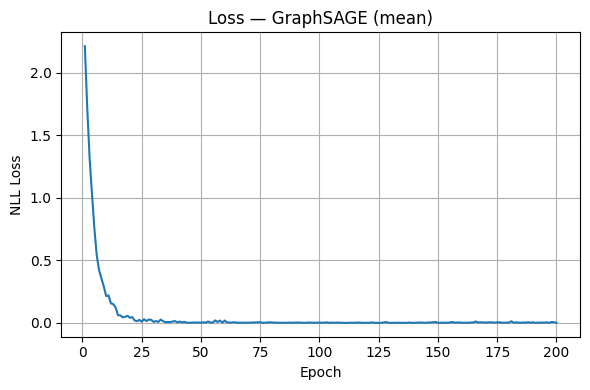

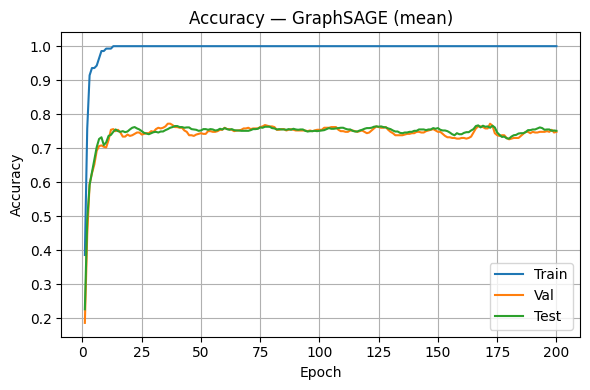


=== Test set metrics — GraphSAGE (mean) ===
              precision    recall  f1-score   support

           0     0.6197    0.6769    0.6471       130
           1     0.8734    0.7582    0.8118        91
           2     0.8562    0.8681    0.8621       144
           3     0.8382    0.7147    0.7716       319
           4     0.7030    0.7785    0.7389       149
           5     0.6864    0.7864    0.7330       103
           6     0.6282    0.7656    0.6901        64

    accuracy                         0.7560      1000
   macro avg     0.7436    0.7641    0.7506      1000
weighted avg     0.7664    0.7560    0.7580      1000

Confusion matrix (rows=true, cols=pred):
[[ 88   4   4  15   6   6   7]
 [  9  69   4   4   3   1   1]
 [  3   1 125  10   0   4   1]
 [ 17   4   8 228  38  14  10]
 [  9   1   2  10 116   8   3]
 [  8   0   3   3   1  81   7]
 [  8   0   0   2   1   4  49]]


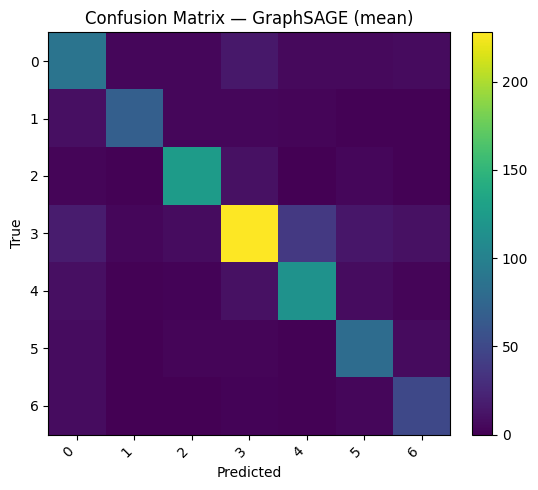

,class_id,precision,recall,f1,support
0,0,0.619718,0.676923,0.647059,130
1,1,0.873418,0.758242,0.811765,91
2,2,0.856164,0.868056,0.862069,144
3,3,0.838235,0.714734,0.771574,319
4,4,0.703030,0.778523,0.738854,149
5,5,0.686441,0.786408,0.733032,103
6,6,0.628205,0.765625,0.690141,64


In [37]:
# use the AE-compressed features (this is what fixed LSTM for you)
data_used = data_128

num_feats = data_used.x.size(1)
num_classes = int(data_used.y.max()) + 1
_ = setup_environment(42)

model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator='mean', dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GraphSAGE (mean)")
_ = print_test_metrics(model, data_used, title_suffix="GraphSAGE (mean)")


### GAT ( 1,2 and 5 heads )

In [38]:
gat_heads_list = [1, 2, 5]  # requested variants
gat_results = {}

_ = setup_environment(42)


for heads in gat_heads_list:
    print(f'\n=== GAT | heads={heads} ===')
    model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=heads, dropout=dropout)  # same hyperparams
    test_acc = run_experiment(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GAT 128 {heads})',count_params(model))
    gat_results[heads] = test_acc

gat_df = pd.DataFrame(
    [{'Heads': h, 'Test Accuracy (%)': round(acc * 100, 2)} for h, acc in gat_results.items()]
).sort_values('Heads').reset_index(drop=True)

print('\nGAT 128 results:')
print(gat_df.to_string(index=False))



Using device: cuda

=== GAT | heads=1 ===
Epoch: 020, Loss: 2.0146, Train: 0.5929, Val: 0.4220, Test: 0.4270
Epoch: 040, Loss: 1.6178, Train: 0.7643, Val: 0.5340, Test: 0.5580
Epoch: 060, Loss: 1.5457, Train: 0.8571, Val: 0.6960, Test: 0.7070
Epoch: 080, Loss: 1.1516, Train: 0.9214, Val: 0.7520, Test: 0.7540
Epoch: 100, Loss: 0.9811, Train: 0.9286, Val: 0.7560, Test: 0.7780
Epoch: 120, Loss: 0.7756, Train: 0.9429, Val: 0.7500, Test: 0.7790
Epoch: 140, Loss: 0.8465, Train: 0.9643, Val: 0.7600, Test: 0.7850
Epoch: 160, Loss: 0.6241, Train: 0.9857, Val: 0.7580, Test: 0.7840
Epoch: 180, Loss: 0.7490, Train: 0.9786, Val: 0.7720, Test: 0.7850
Epoch: 200, Loss: 0.7115, Train: 0.9929, Val: 0.7720, Test: 0.8000
Params (GAT 128 1) 8853

=== GAT | heads=2 ===
Epoch: 020, Loss: 1.4387, Train: 0.8286, Val: 0.6620, Test: 0.6250
Epoch: 040, Loss: 0.8904, Train: 0.9071, Val: 0.7660, Test: 0.7620
Epoch: 060, Loss: 0.8022, Train: 0.9429, Val: 0.7820, Test: 0.7850
Epoch: 080, Loss: 0.6704, Train: 0.9571,

### 2 head gives best results

Using device: cuda
Epoch 020 | Loss 1.7374 | Train 0.6857 | Val 0.5260 | Test 0.5290
Epoch 040 | Loss 1.2672 | Train 0.8929 | Val 0.7080 | Test 0.7190
Epoch 060 | Loss 0.9271 | Train 0.9357 | Val 0.7820 | Test 0.7870
Epoch 080 | Loss 0.7385 | Train 0.9571 | Val 0.7780 | Test 0.7940
Epoch 100 | Loss 0.6287 | Train 0.9857 | Val 0.7700 | Test 0.7840
Epoch 120 | Loss 0.5501 | Train 0.9929 | Val 0.7680 | Test 0.7740
Epoch 140 | Loss 0.5737 | Train 0.9857 | Val 0.7560 | Test 0.7720
Epoch 160 | Loss 0.6074 | Train 0.9857 | Val 0.7560 | Test 0.7700
Epoch 180 | Loss 0.3554 | Train 0.9929 | Val 0.7560 | Test 0.7810
Epoch 200 | Loss 0.6218 | Train 1.0000 | Val 0.7660 | Test 0.7910


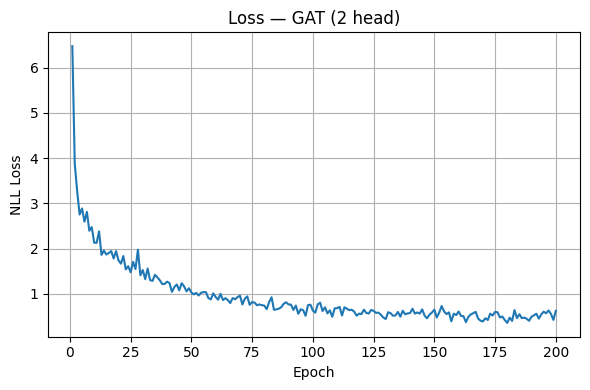

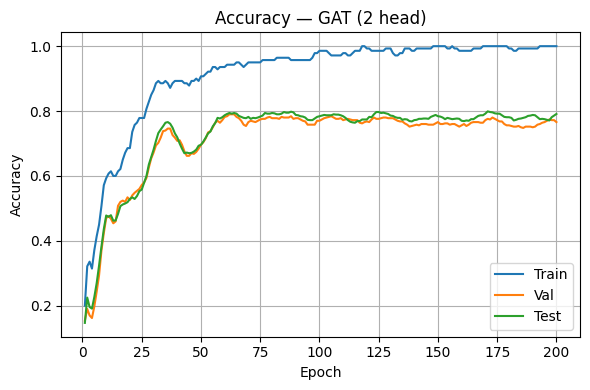


=== Test set metrics — GAT (2 head ===
              precision    recall  f1-score   support

           0     0.7664    0.6308    0.6920       130
           1     0.7921    0.8791    0.8333        91
           2     0.8000    0.9444    0.8662       144
           3     0.8700    0.7555    0.8087       319
           4     0.7167    0.8658    0.7842       149
           5     0.8020    0.7864    0.7941       103
           6     0.7031    0.7031    0.7031        64

    accuracy                         0.7940      1000
   macro avg     0.7786    0.7950    0.7831      1000
weighted avg     0.7988    0.7940    0.7922      1000

Confusion matrix (rows=true, cols=pred):
[[ 82   7   7  13   9   7   5]
 [  0  80   5   5   1   0   0]
 [  1   3 136   2   2   0   0]
 [  3   6  18 241  36   7   8]
 [  3   2   0  12 129   3   0]
 [  8   2   4   1   1  81   6]
 [ 10   1   0   3   2   3  45]]


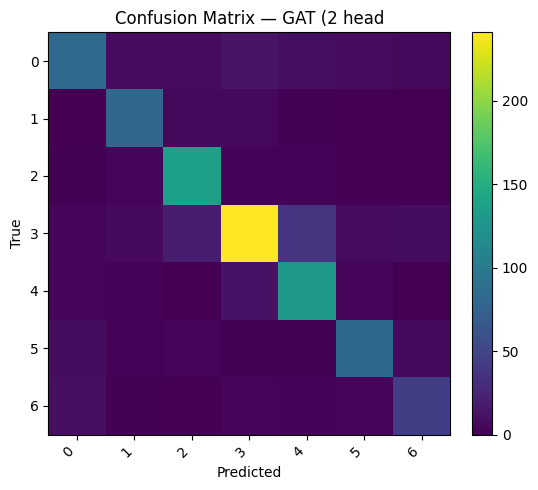

,class_id,precision,recall,f1,support
0,0,0.766355,0.630769,0.691983,130
1,1,0.792079,0.879121,0.833333,91
2,2,0.800000,0.944444,0.866242,144
3,3,0.870036,0.755486,0.808725,319
4,4,0.716667,0.865772,0.784195,149
5,5,0.801980,0.786408,0.794118,103
6,6,0.703125,0.703125,0.703125,64


In [39]:
_ = setup_environment(42)

model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=2, dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GAT (2 head)")
_ = print_test_metrics(model, data_used, title_suffix="GAT (2 head")

### Comparison

In [40]:
# Simple comparison table (best of each family)
best_gat_heads = max(gat_results, key=lambda h: gat_results[h])
compare_df = pd.DataFrame({
    'Model': ['GraphSAGE (best)', 'GAT (best)'],
    'Config': [f'Aggregator={best_aggr}', f'Heads={best_gat_heads}'],
    'Test Accuracy (%)': [round(sage_results[best_aggr]*100, 2), round(gat_results[best_gat_heads]*100, 2)]
})
print('\nComparison:')
print(compare_df.to_string(index=False))



Comparison:
           Model          Config  Test Accuracy (%)
GraphSAGE (best) Aggregator=mean               75.6
      GAT (best)         Heads=2               79.4


## Reduced features via autoencoder ( dim = 256 )

In [41]:
proj_dim = 256
_ = setup_environment(42)

ae = pretrain_autoencoder_features(data, proj_dim=proj_dim, epochs=100, lr=1e-3, weight_decay=1e-5, dropout=0.1, device=device)
data_256 = apply_encoder_to_data(data, ae, device=device)


Using device: cuda
[AE] Epoch 020 | recon MSE 0.882066
[AE] Epoch 040 | recon MSE 0.787385
[AE] Epoch 060 | recon MSE 0.727086
[AE] Epoch 080 | recon MSE 0.687896
[AE] Epoch 100 | recon MSE 0.657631
Replaced features: 1433 → 256


### Hyperparameters

In [42]:
hidden = 64
dropout = 0.5
epochs = 200
lr = 0.01
weight_decay = 5e-4
num_feats = data_256.x.size(1)

### GraphSAGE ( mean , max , lstm )

In [43]:
_ = setup_environment(42)
aggregators = ['mean', 'max','lstm']  # lstm is supported by SAGEConv.  # see docs
sage_results = {}

for aggr in aggregators:
    print(f'\n=== GraphSAGE | aggr={aggr} ===')
    model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator=aggr, dropout=dropout)
    test_acc = run_experiment(model, data_256, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GraphSAGE 256 {aggr})',count_params(model))
    sage_results[aggr] = test_acc

sage_df = pd.DataFrame(
    [{'Aggregator': k, 'Test Accuracy (%)': round(v * 100, 2)} for k, v in sage_results.items()]
).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

best_aggr = sage_df.loc[0, 'Aggregator']
print('\nGraphSAGE 256 results:')
print(sage_df.to_string(index=False))
print(f'\nBest GraphSAGE aggregator: {best_aggr}')


Using device: cuda

=== GraphSAGE | aggr=mean ===
Epoch: 020, Loss: 0.1071, Train: 0.9929, Val: 0.7380, Test: 0.7370
Epoch: 040, Loss: 0.0393, Train: 1.0000, Val: 0.7420, Test: 0.7370
Epoch: 060, Loss: 0.0342, Train: 1.0000, Val: 0.7620, Test: 0.7610
Epoch: 080, Loss: 0.0083, Train: 1.0000, Val: 0.7460, Test: 0.7360
Epoch: 100, Loss: 0.0080, Train: 1.0000, Val: 0.7660, Test: 0.7670
Epoch: 120, Loss: 0.0024, Train: 1.0000, Val: 0.7500, Test: 0.7670
Epoch: 140, Loss: 0.0089, Train: 1.0000, Val: 0.7320, Test: 0.7570
Epoch: 160, Loss: 0.0190, Train: 1.0000, Val: 0.7400, Test: 0.7470
Epoch: 180, Loss: 0.0083, Train: 1.0000, Val: 0.7420, Test: 0.7310
Epoch: 200, Loss: 0.0100, Train: 1.0000, Val: 0.7360, Test: 0.7660
Params (GraphSAGE 256 mean) 33735

=== GraphSAGE | aggr=max ===
Epoch: 020, Loss: 0.6459, Train: 0.8857, Val: 0.5420, Test: 0.5500
Epoch: 040, Loss: 0.1499, Train: 1.0000, Val: 0.6580, Test: 0.7160


/usr/local/lib/python3.12/dist-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


Epoch: 060, Loss: 0.0391, Train: 1.0000, Val: 0.6620, Test: 0.6920
Epoch: 080, Loss: 0.0398, Train: 1.0000, Val: 0.7060, Test: 0.7360
Epoch: 100, Loss: 0.0447, Train: 1.0000, Val: 0.6960, Test: 0.6930
Epoch: 120, Loss: 0.0280, Train: 1.0000, Val: 0.7020, Test: 0.7110
Epoch: 140, Loss: 0.0529, Train: 1.0000, Val: 0.6920, Test: 0.6840
Epoch: 160, Loss: 0.0198, Train: 1.0000, Val: 0.7080, Test: 0.7230
Epoch: 180, Loss: 0.0079, Train: 1.0000, Val: 0.7080, Test: 0.7040
Epoch: 200, Loss: 0.0191, Train: 1.0000, Val: 0.6960, Test: 0.7240
Params (GraphSAGE 256 max) 33735

=== GraphSAGE | aggr=lstm ===
Epoch: 020, Loss: 0.1397, Train: 1.0000, Val: 0.5220, Test: 0.5350
Epoch: 040, Loss: 0.0491, Train: 1.0000, Val: 0.5500, Test: 0.5560
Epoch: 060, Loss: 0.0278, Train: 1.0000, Val: 0.5420, Test: 0.5530
Epoch: 080, Loss: 0.0122, Train: 1.0000, Val: 0.5460, Test: 0.5560
Epoch: 100, Loss: 0.0231, Train: 1.0000, Val: 0.5740, Test: 0.5830
Epoch: 120, Loss: 0.0236, Train: 1.0000, Val: 0.5540, Test: 0.564

### Mean gives best results

Using device: cuda
Epoch 020 | Loss 0.1071 | Train 0.9929 | Val 0.7380 | Test 0.7370
Epoch 040 | Loss 0.0393 | Train 1.0000 | Val 0.7420 | Test 0.7370
Epoch 060 | Loss 0.0342 | Train 1.0000 | Val 0.7620 | Test 0.7610
Epoch 080 | Loss 0.0083 | Train 1.0000 | Val 0.7460 | Test 0.7360
Epoch 100 | Loss 0.0080 | Train 1.0000 | Val 0.7660 | Test 0.7670
Epoch 120 | Loss 0.0024 | Train 1.0000 | Val 0.7500 | Test 0.7670
Epoch 140 | Loss 0.0089 | Train 1.0000 | Val 0.7320 | Test 0.7570
Epoch 160 | Loss 0.0190 | Train 1.0000 | Val 0.7400 | Test 0.7470
Epoch 180 | Loss 0.0083 | Train 1.0000 | Val 0.7420 | Test 0.7310
Epoch 200 | Loss 0.0100 | Train 1.0000 | Val 0.7360 | Test 0.7660


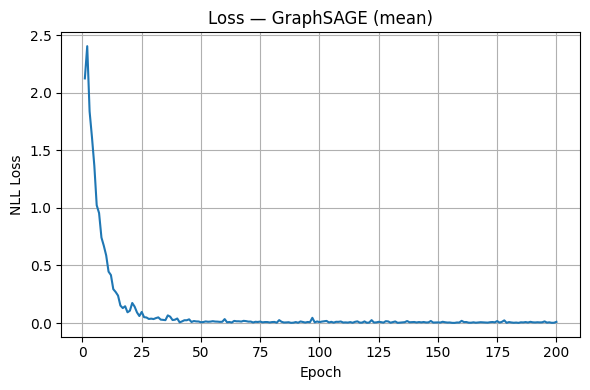

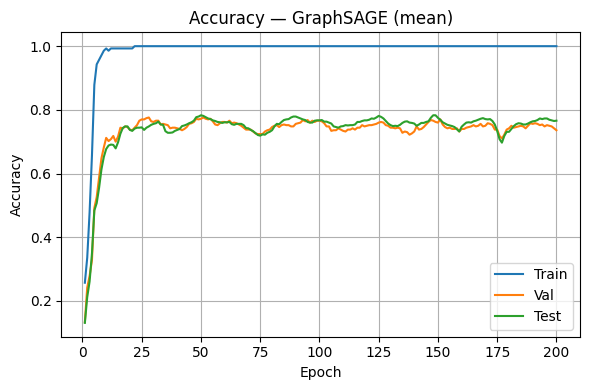


=== Test set metrics — GraphSAGE (mean) ===
              precision    recall  f1-score   support

           0     0.6612    0.6154    0.6375       130
           1     0.8452    0.7802    0.8114        91
           2     0.7399    0.8889    0.8076       144
           3     0.8755    0.6614    0.7536       319
           4     0.6597    0.8456    0.7412       149
           5     0.7105    0.7864    0.7465       103
           6     0.6711    0.7969    0.7286        64

    accuracy                         0.7480      1000
   macro avg     0.7376    0.7678    0.7466      1000
weighted avg     0.7631    0.7480    0.7473      1000

Confusion matrix (rows=true, cols=pred):
[[ 80   3   6  11  14   8   8]
 [  6  71   6   4   4   0   0]
 [  4   4 128   6   2   0   0]
 [ 10   4  28 211  40  18   8]
 [ 11   1   2   4 126   4   1]
 [  5   1   2   5   1  81   8]
 [  5   0   1   0   4   3  51]]


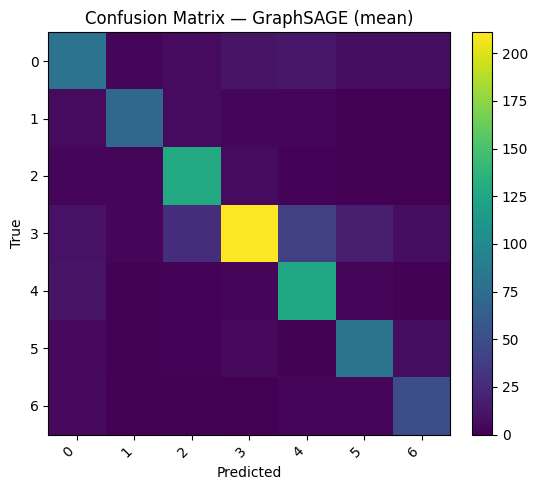

,class_id,precision,recall,f1,support
0,0,0.661157,0.615385,0.637450,130
1,1,0.845238,0.780220,0.811429,91
2,2,0.739884,0.888889,0.807571,144
3,3,0.875519,0.661442,0.753571,319
4,4,0.659686,0.845638,0.741176,149
5,5,0.710526,0.786408,0.746544,103
6,6,0.671053,0.796875,0.728571,64


In [44]:
# use the AE-compressed features (this is what fixed LSTM for you)
data_used = data_256

num_feats = data_used.x.size(1)
num_classes = int(data_used.y.max()) + 1
_ = setup_environment(42)

model = GraphSAGE(num_feats, hidden, num_classes, num_layers=2, aggregator='mean', dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GraphSAGE (mean)")
_ = print_test_metrics(model, data_used, title_suffix="GraphSAGE (mean)")


### GAT ( 1,2 and 5 heads )

In [45]:
gat_heads_list = [1, 2, 5]  # requested variants
gat_results = {}

_ = setup_environment(42)


for heads in gat_heads_list:
    print(f'\n=== GAT | heads={heads} ===')
    model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=heads, dropout=dropout)  # same hyperparams
    test_acc = run_experiment(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay)
    print(f'Params (GAT 256 {heads})',count_params(model))
    gat_results[heads] = test_acc

gat_df = pd.DataFrame(
    [{'Heads': h, 'Test Accuracy (%)': round(acc * 100, 2)} for h, acc in gat_results.items()]
).sort_values('Heads').reset_index(drop=True)

print('\nGAT 256 results:')
print(gat_df.to_string(index=False))



Using device: cuda

=== GAT | heads=1 ===
Epoch: 020, Loss: 1.8252, Train: 0.7000, Val: 0.5100, Test: 0.4910
Epoch: 040, Loss: 1.6000, Train: 0.8929, Val: 0.6320, Test: 0.6480
Epoch: 060, Loss: 1.1134, Train: 0.9357, Val: 0.7500, Test: 0.7650
Epoch: 080, Loss: 0.8306, Train: 0.9500, Val: 0.7720, Test: 0.7700
Epoch: 100, Loss: 0.6705, Train: 0.9929, Val: 0.7740, Test: 0.8020
Epoch: 120, Loss: 0.6446, Train: 0.9857, Val: 0.7900, Test: 0.8090
Epoch: 140, Loss: 0.5010, Train: 0.9857, Val: 0.7660, Test: 0.7740
Epoch: 160, Loss: 0.5934, Train: 0.9857, Val: 0.7660, Test: 0.7870
Epoch: 180, Loss: 0.5801, Train: 0.9857, Val: 0.7780, Test: 0.7820
Epoch: 200, Loss: 0.6147, Train: 0.9857, Val: 0.7720, Test: 0.7860
Params (GAT 256 1) 17045

=== GAT | heads=2 ===
Epoch: 020, Loss: 1.6077, Train: 0.8000, Val: 0.6240, Test: 0.6400
Epoch: 040, Loss: 0.9586, Train: 0.9214, Val: 0.7220, Test: 0.7270
Epoch: 060, Loss: 0.8885, Train: 0.9500, Val: 0.7400, Test: 0.7470
Epoch: 080, Loss: 0.6339, Train: 0.9857

### 2 head gives bset results

Using device: cuda
Epoch 020 | Loss 2.1483 | Train 0.5071 | Val 0.3700 | Test 0.3710
Epoch 040 | Loss 1.3747 | Train 0.8786 | Val 0.6020 | Test 0.6060
Epoch 060 | Loss 1.1691 | Train 0.9214 | Val 0.6920 | Test 0.7030
Epoch 080 | Loss 0.7827 | Train 0.9357 | Val 0.7300 | Test 0.7280
Epoch 100 | Loss 0.6686 | Train 0.9857 | Val 0.7700 | Test 0.7890
Epoch 120 | Loss 0.6646 | Train 0.9857 | Val 0.7780 | Test 0.7930
Epoch 140 | Loss 0.6224 | Train 0.9714 | Val 0.7300 | Test 0.7620
Epoch 160 | Loss 0.5104 | Train 0.9857 | Val 0.7740 | Test 0.7990
Epoch 180 | Loss 0.6375 | Train 0.9786 | Val 0.7660 | Test 0.7810
Epoch 200 | Loss 0.4639 | Train 0.9929 | Val 0.7660 | Test 0.7830


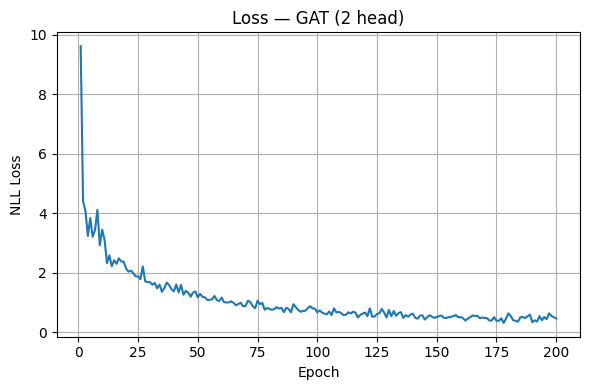

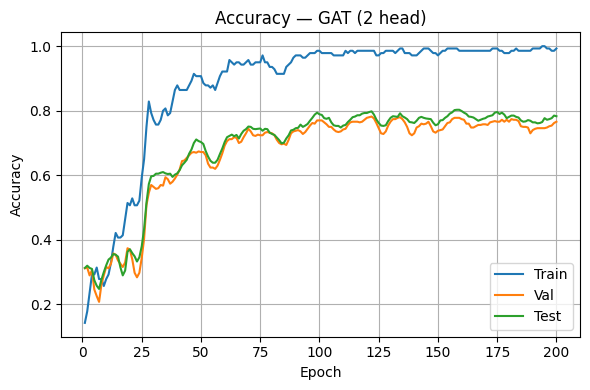


=== Test set metrics — GAT (2 head ===
              precision    recall  f1-score   support

           0     0.6618    0.6923    0.6767       130
           1     0.7629    0.8132    0.7872        91
           2     0.8313    0.9236    0.8750       144
           3     0.8741    0.7837    0.8264       319
           4     0.7834    0.8255    0.8039       149
           5     0.8000    0.7767    0.7882       103
           6     0.7500    0.7500    0.7500        64

    accuracy                         0.7980      1000
   macro avg     0.7805    0.7950    0.7868      1000
weighted avg     0.8011    0.7980    0.7982      1000

Confusion matrix (rows=true, cols=pred):
[[ 90   4   3  14   9   3   7]
 [  4  74   5   6   1   1   0]
 [  3   4 133   4   0   0   0]
 [ 12   9  15 250  23   8   2]
 [  9   3   0  11 123   2   1]
 [  8   3   4   1   1  80   6]
 [ 10   0   0   0   0   6  48]]


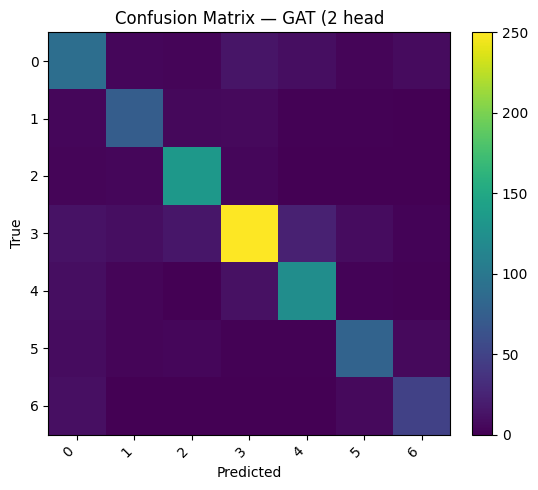

,class_id,precision,recall,f1,support
0,0,0.661765,0.692308,0.676692,130
1,1,0.762887,0.813187,0.787234,91
2,2,0.831250,0.923611,0.875000,144
3,3,0.874126,0.783699,0.826446,319
4,4,0.783439,0.825503,0.803922,149
5,5,0.800000,0.776699,0.788177,103
6,6,0.750000,0.750000,0.750000,64


In [46]:
_ = setup_environment(42)

model = GAT(num_feats, hidden, num_classes, num_layers=2, heads=2, dropout=dropout)
model, history, best = run_and_log(model, data_used, device, epochs=epochs, lr=lr, weight_decay=weight_decay, print_every=20)

plot_curves(history, title_suffix="GAT (2 head)")
_ = print_test_metrics(model, data_used, title_suffix="GAT (2 head")

## Comparison

In [47]:
# Simple comparison table (best of each family)
best_gat_heads = max(gat_results, key=lambda h: gat_results[h])
compare_df = pd.DataFrame({
    'Model': ['GraphSAGE (best)', 'GAT (best)'],
    'Config': [f'Aggregator={best_aggr}', f'Heads={best_gat_heads}'],
    'Test Accuracy (%)': [round(sage_results[best_aggr]*100, 2), round(gat_results[best_gat_heads]*100, 2)]
})
print('\nComparison:')
print(compare_df.to_string(index=False))



Comparison:
           Model          Config  Test Accuracy (%)
GraphSAGE (best) Aggregator=mean               74.8
      GAT (best)         Heads=2               79.7
